# Red neuronal para estimar los inscritos para una convocatoria

### Instalación de librerias

In [ ]:
#pip install pandas psycopg2 sqlalchemy unidecode mlflow keras tensorflow seaborn statsmodels xlsxwriter 
#pip install streamlit, flask_restful flask_cors geopy folium

In [ ]:
#!pip install -r "C:\\Users\\jlmartinez\\Costos\\requeriments.txt"
#!pip install scikeras
#!pip install sklearn
#!pip install -U protobuf==3.20.*
#!pip install -U pyOpenSSL
#!pip install "numpy<2"

In [1]:
#!pip freeze
import subprocess

output = subprocess.run(["pip", "freeze"], capture_output=True, text=True)
filtered_output = [line for line in output.stdout.splitlines() if "==" in line]
print("\n".join(filtered_output))

absl-py==2.2.2
appdirs==1.4.4
astunparse==1.6.3
atomicwrites==1.4.0
flatbuffers==25.2.10
fuzzywuzzy==0.18.0
gast==0.6.0
google-pasta==0.2.0
grpcio==1.71.0
jsonpointer==2.1
keras==3.9.2
libclang==18.1.1
lxml==5.2.1
matplotlib==3.9.2
mkl-service==2.4.0
ml_dtypes==0.5.1
namex==0.0.8
opt_einsum==3.4.0
optree==0.15.0
psycopg2==2.9.10
pyasn1-modules==0.2.8
pyls-spyder==0.4.0
PyQt6==6.9.1
PyQt6-WebEngine==6.9.0
PySide6==6.9.2
pywin32==305.1
RapidFuzz==3.12.1
setuptools==80.9.0
shiboken6==6.9.2
tensorboard==2.19.0
tensorboard-data-server==0.7.2
tensorflow==2.19.0
termcolor==3.0.1
wheel==0.44.0
XlsxWriter==3.2.2


In [2]:
pip freeze > requeriments.txt

Note: you may need to restart the kernel to use updated packages.


# 
## Librerias Generales

In [1]:
#librerias
import io
import pandas as pd
import time
from datetime import datetime

# Maximo de columnas
pd.options.display.max_columns = None
import warnings
warnings.filterwarnings('ignore')

In [2]:
%%time
# Importar funciones
from src.A_Generales import *
from src.B_Historico import *
from src.C_RedNeuronal import fEscenarios, fEntrenamiento, fProyeccion
from src.D_GuardarBD import fGuardarResultados
from src.E_Resultados import fResultadosExcel, fResultadosTexto, fResultadosGraficas, rArchivoZip

CPU times: total: 1.39 s
Wall time: 6.05 s


# 
# Ejecución de la red neuronal

### Leer Histórico de SIMO

In [3]:
%%time
lprint("Inicia Pipeline \n\n")
dfEmpleo = rDatosSimo()

2025-12-01 23:21:41,143 - INFO - 2025-Dec-01-23:21:41, Inicia Pipeline 



2025-12-01 23:21:41,144 - INFO - 2025-Dec-01-23:21:41, Inicio - Crear y Leer historico de Simo

2025-12-01 23:21:41,224 - INFO - 2025-Dec-01-23:21:41, Consulta de los días para actualizar nn_simo

2025-12-01 23:21:41,317 - INFO - 2025-Dec-01-23:21:41, Consulta fecha última actualización nn_simo

2025-12-01 23:21:41,521 - INFO - 2025-Dec-01-23:21:41, Calcular diferencia de días

2025-12-01 23:21:41,697 - INFO - 2025-Dec-01-23:21:41, FIN de lectura de nn_simo 




CPU times: total: 46.9 ms
Wall time: 556 ms


In [4]:
dfEmpleo.tail(3)

,empleo_id,identificador,asignacion_salarial,vigencia_salarial,concurso_ascenso,grado_nivel_id,nivelid,nivel,grado,denominacion,conv_id,conv_nombre,conv_agno,conv_estado,conv_padre_id,conv_padre,entidad,nit,tipo_entidad,reqs_estudio,nbc_tecnico,nbc_esp_tecnico,nbc_tecnologico,nbc_esp_tecnologico,nbc_profesional,nbc_esp_profesional,nbc_maestria,nbc_doctorado,departamento,municipio,codigo_dane,vacantes_opec,vacantes_municipios,vacantes,inscritos,aprobo_vrm,aprobo_escritas,mun_inscritos,mun_aprobo_vrm,mun_aprobo_escritas,pcd_inscritos,mun_pcd_inscritos,pcd_psicosocial,pcd_intelectual,pcd_auditiva,pcd_visual,pcd_fisica,pcd_multiple,pcd_sordoceguera,fecha_actualizacion,mun_categoria,criterio_id,experiencia,exp_profesional,exp_prof_relacionada,exp_laboral,exp_labo_relacionada,exp_relacionada,etiqueta,sin_experiencia,agno,smmlv
72641,243492,183,4065092,2024,False,59336042,10,Instructor,1,INSTRUCTOR,925896052,SERVICIO NACIONAL DE APRENDIZAJE- SENA 2024. A...,2024,A,925895515,PROCESO DE SELECCIÓN SERVICIO NACIONAL DE APRE...,SERVICIO NACIONAL DE APRENDIZAJE- SENA,899999034,Servicio Nacional de Aprendizaje SENA,None,None,None,None,None,None,None,None,None,Valle del Cauca,Cali,76001,1,1,1,12,0,0,12,0,0,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-11-27 16:21:37.048255+00:00,7,1179780371,doce 12 meses de experiencia relacionada <br/>...,0,0,0,0,1,False,False,2024,3.13
72642,243493,149,5848204,2024,False,48,3,Profesional,2,PROFESIONAL,925896052,SERVICIO NACIONAL DE APRENDIZAJE- SENA 2024. A...,2024,A,925895515,PROCESO DE SELECCIÓN SERVICIO NACIONAL DE APRE...,SERVICIO NACIONAL DE APRENDIZAJE- SENA,899999034,Servicio Nacional de Aprendizaje SENA,None,None,None,None,None,None,None,None,None,Bogotá D.C.,Bogotá D.C.,11001,1,1,1,86,0,0,86,0,0,1,1.0,0,0,0,0,1,0,0,2025-11-27 16:21:37.048255+00:00,7,1179780382,seis 6 meses de experiencia profesional relaci...,0,1,0,0,0,False,False,2024,4.50
72643,243494,250,4065092,2024,False,59336042,10,Instructor,1,INSTRUCTOR,925896052,SERVICIO NACIONAL DE APRENDIZAJE- SENA 2024. A...,2024,A,925895515,PROCESO DE SELECCIÓN SERVICIO NACIONAL DE APRE...,SERVICIO NACIONAL DE APRENDIZAJE- SENA,899999034,Servicio Nacional de Aprendizaje SENA,None,None,None,None,None,None,None,None,None,Cundinamarca,Mosquera,25473,1,1,1,22,0,0,22,0,0,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-11-27 16:21:37.048255+00:00,1,1179780393,doce 12 meses de experiencia relacionada <br/>...,0,0,0,0,1,False,False,2024,3.13


### Leer los escenarios y Elaborar el diccionario

### Realiza el entrenamiento de cada escenario

In [5]:
%%time
lprint("Inicio - Realizar entrenamiento de escenarios")
Dict = fEntrenamiento(dfEmpleo, False)

2025-12-01 23:21:46,163 - INFO - 2025-Dec-01-23:21:46, Inicio - Realizar entrenamiento de escenarios

2025-12-01 23:21:46,164 - INFO - 2025-Dec-01-23:21:46, Inicio - Realizar entrenamiento de escenarios

2025-12-01 23:21:46,366 - INFO - 2025-Dec-01-23:21:46, Inicio - Creación de escenarios en base al historico de Simo

2025-12-01 23:21:46,566 - INFO - 2025-Dec-01-23:21:46, Nacional

2025-12-01 23:21:46,569 - INFO - 2025-Dec-01-23:21:46, tipo_entidad==Nacional

2025-12-01 23:21:46,796 - INFO - 2025-Dec-01-23:21:46, Primer Fila (16479, 62) / 44 / Nacional / tipo_entidad / == / Nacional / 20.0 / 100.0 / AND

2025-12-01 23:21:46,798 - INFO - 2025-Dec-01-23:21:46, Nacional

2025-12-01 23:21:46,825 - INFO - 2025-Dec-01-23:21:46, FINAL (16479, 62) / 44 / Nacional / agno / > / 2020 / 0.0 / 100.0 /  / 2 / 442

2025-12-01 23:21:46,826 - INFO - 2025-Dec-01-23:21:46, 
 Escenarios aprobados: 

2025-12-01 23:21:46,827 - INFO - 2025-Dec-01-23:21:46, Nacional-0 (13858, 62)

2025-12-01 23:21:46,828 - I


Epoch 1: val_loss improved from None to 0.94432, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 2: val_loss improved from 0.94432 to 0.86748, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 3: val_loss improved from 0.86748 to 0.84445, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 4: val_loss improved from 0.84445 to 0.82058, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 5: val_loss improved from 0.82058 to 0.81742, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 6: val_loss improved from 0.81742 to 0.81239, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 7: val_loss improved from 0.81239 to 0.79187, saving model to Mejor escenario: Escena44-0_red_4.keras

Epoch 8: val_loss did not improve from 0.79187

Epoch 9: val_loss did not improve from 0.79187

Epoch 10: val_loss did not improve from 0.79187

Epoch 11: val_loss did not improve from 0.79187

Epoch 12: val_loss improved from 0.79187 to 0

2025-12-01 23:22:15,665 - INFO - 2025-Dec-01-23:22:15, Escenario Nacional-0 / Modelo 1 ajustado




Epoch 1: val_loss improved from None to 1.02671, saving model to Mejor escenario: Escena44-1_red_4.keras

Epoch 2: val_loss improved from 1.02671 to 1.00752, saving model to Mejor escenario: Escena44-1_red_4.keras

Epoch 3: val_loss did not improve from 1.00752

Epoch 4: val_loss did not improve from 1.00752

Epoch 5: val_loss improved from 1.00752 to 0.99438, saving model to Mejor escenario: Escena44-1_red_4.keras

Epoch 6: val_loss did not improve from 0.99438

Epoch 7: val_loss improved from 0.99438 to 0.97689, saving model to Mejor escenario: Escena44-1_red_4.keras

Epoch 8: val_loss did not improve from 0.97689

Epoch 9: val_loss did not improve from 0.97689

Epoch 10: val_loss did not improve from 0.97689

Epoch 11: val_loss did not improve from 0.97689

Epoch 12: val_loss did not improve from 0.97689

Epoch 13: val_loss did not improve from 0.97689

Epoch 14: val_loss did not improve from 0.97689

Epoch 15: val_loss did not improve from 0.97689

Epoch 16: val_loss did not impro

2025-12-01 23:22:46,119 - INFO - 2025-Dec-01-23:22:46, Escenario Nacional-1 / Modelo 2 ajustado

2025-12-01 23:22:57,323 - INFO - 2025-Dec-01-23:22:57, FIN de entrenamiento de escenarios 




CPU times: total: 12.2 s
Wall time: 1min 11s


### Seleccionar convocatoria

In [6]:
%%time
id_convocatoria = 925895515
lprint("Inicio - Seleccionar convocatoria a proyectar")
dfCostos, co = rConvocatoriaSimo(id_convocatoria)
lprint("FIN de proyección de convocatoria")

2025-12-01 23:24:12,177 - INFO - 2025-Dec-01-23:24:12, Inicio - Seleccionar convocatoria a proyectar

2025-12-01 23:24:12,178 - INFO - 2025-Dec-01-23:24:12, Inicio - Seleccionar convocatoria a proyectar

2025-12-01 23:24:12,228 - INFO - 2025-Dec-01-23:24:12, La convocatoria es: 925895515

2025-12-01 23:24:12,308 - INFO - 2025-Dec-01-23:24:12, Consulta de la convocatoria '925895515'

2025-12-01 23:24:12,624 - INFO - 2025-Dec-01-23:24:12, Inicio consulta sql/convocatorias.sql

2025-12-01 23:24:14,298 - INFO - 2025-Dec-01-23:24:14, Fin consulta sql/convocatorias.sql (1281, 35)

2025-12-01 23:24:14,427 - INFO - 2025-Dec-01-23:24:14, Inicio consulta sql/experiencia.sql

2025-12-01 23:24:23,907 - INFO - 2025-Dec-01-23:24:23, Fin consulta sql/experiencia.sql (176042, 10)

2025-12-01 23:24:23,946 - INFO - 2025-Dec-01-23:24:23, Cruce con los municipios y la experiencia

2025-12-01 23:24:24,027 - INFO - 2025-Dec-01-23:24:24, DataFrame de tabla public.salario_minimo

2025-12-01 23:24:24,094 - INF

CPU times: total: 578 ms
Wall time: 11.9 s


### Seleccionar por Cargo

In [13]:
# Docentes 
#empleos = (184713,184716,241973,241974,241975,241976,241977,241978,241979,241980,241981,241982,241984,241986,241987,241988,241989,241990,241991,241992,242989,242990,242991,242992,243010,243011,243012,243013,243014,243015,243016,243017,243018,243019,243020,243021,242182,242183,242184,242185,242186,242187,242188,242189,242190,242191,242192,242193,242194,242195,242196,242197,242198,242199,242200,242201,242202,242957,241679,241680,241681,241682,241683,241684,243151,242859,242860,242861,242862,242863,242864,242865,242866,242867,242868,242870,242871,242872,242874,242875,242877,242878,242879,242880,242881,241950,241951,241952,241953,241954,241955,241956,241957,241958,241959,241960,241961,241962,241963,241964,243660,243824,243825,243826,243827,242167,242168,242169,242170,242171,242172,242173,242174,242175,242176,242177,242178,242179,242180,242181,242833,242834,242836,242839,241639,241641,241643,241646,241649,241651,241653,241655,241656,241657,241658,241660,241662,241665,241667,242845,242712,242713,242714,242716,242717,242718,242719,242720,242721,241729,241730,241731,241732,241847,241848,241849,241852,241853,241854,241855,241856,242707,242959,184825,241364,241367,241488,241493,241560,241563,241568,241570,241571,241573,241577,241582,241585,241588,243517,243518,241759,241761,241765,241811,241825,241826,241829,241830,241832,241834,241835,241836,241838,241839,241842,241843,241844,241845,241846,243237,242401,242417,242418,242419,242420,242421,242422,242423,242518,242519,242520,242521,242522,242523,242524,242525,242526,242527,242528,242530,242531,242532,243479,165554,241929,241931,241932,241934,241935,241936,241938,241939,241940,241941,241942,241943,241945,241946,241947,241948,242736,241857,241858,241859,241860,241861,241862,241863,241865,241866,241867,241891,241905,241906,241907,241908,243323,243324,184353,241454,241463,241464,241466,241467,241471,241473,241474,241477,241479,241480,241481,241483,241484,241486,241487,241490,241492,241495,241497,241499,241376,241404,241451,241462,241465,241468,241472,243041,243042,243043,243044,243045,243046,243047,243048,243049,243053,243054,243055,243056,243057,243058,243059,243061,243062,243063,241284,241310,241314,241318,241321,241325,242948,242949,242950,241572,241575,241579,241581,241586,241589,241592,241594,241597,241599,241601,241606,241612,241616,241618,241622,241625,243175,242805,242806,242807,242808,242810,242812,242813,242814,242816,242817,242818,242819,242820,242821,242822,242823,242824,242825,242826,242971,242978,242979,242980,242981,242984,242985,242986,242987,242988,242993,242994,242995,243002,242024,242206,243370,243371,243430,242400,242403,242404,242405,242406,242407,242408,242409,242411,242412,242413,242414,242415,243986,242216,242217,242218,242219,242220,242221,242222,241574,241576,241578,241580,241583,241584,241587,242711,243329,243350,243353,243354,243356,243357,243358,241489,241494,241496,241498,241500,241503,241506,241511,243341,243355,242472,242473,242474,242475,242476,242477,242479,242480,242482,242483,242453,242454,242455,242456,242457,242458,242459,242460,242461,242462,242463,242464,243557,242019,242020,242021,242022,242023,242025,242026,242027,242028,242029,242030,242031,242032,242033,243140,243143,243452,241733,241734,241736,241737,241738,241739,241740,241741,241742,241743,241744,241745,241747,241748,241750,241755,242298,242299,242300,242302,242303,242304,242305,242306,242307,242310,242311,242314,242315,242316,243242,243243,243244,242048,242050,242051,242052,242053,242054,242056,242057,243835,243938,243939,243940,241546,241548,241551,241554,241720,241724,241726,241728,242739,242743,242804,242827,241301,241303,241304,241307,241309,241313,241706,241714,243497,241983,241985,242725,242726,242727,242728,241685,241686,241687,241694,241695,241696,241697,241698,241312,241316,241327,241329,241331,241349,241350,241352,241317,241322,241326,241330,241333,241337,241342,241343,241344,241345,243438,243439,243441,243443,241375,241377,241378,241379,241381,243394,242498,242499,242500,242501,242502,242503,242504,242505,242506,242507,242508,242509,242510,242511,242513,242841,241502,241504,241505,241508,241512,241514,241515,241516,241517,241519,241521,241522,241525,241526,241530,241531,241534,241993,241994,241995,241996,241997,241998,241999,242000,243405,242722,242740,242742,242744,242745,242746,242747,242794,241593,241596,241598,241603,241608,241636,241637,241638,241640,241644,241648,242873,241273,241275,241276,241281,243366,243373,243374,243376,243377,243378,243379,242209,242210,242211,242213,242704,243658,243659,241827,241828,241831,241837,241841,241965,241966,241967,241968,241969,241970,241971,242750,242751,242752,242753,242754,242755,242756,242757,242758,242759,242760,242761,242762,242763,242764,242765,241366,241369,241370,241372,241373,242958,242960,242241,242242,242243,242246,242254,242258,242262,242265,242268,242270,242273,242275,242276,242277,242278,243625,243627,242795,242796,242797,242798,242799,242800,242801,242802,242803,241291,241293,241295,241298,241299,241300,241302,242830,242831,242832,242835,241689,241690,241693,242846,242848,242849,242850,242851,243176,243849,243850,243853,243854,243874,243875,243876,243877,243878,243879,243880,241277,241279,241282,241283,243459,243472,243473,243474,243475,241550,241552,241557,241559,241562,241564,241565,241567,241569,241501,241509,241527,241532,241538,241539,241542,241544,241545,241549,241553,241555,241558,241561,241566,242970,242982,242983,241708,241710,241712,241713,241715,241716,241717,241719,241723,241725,243185,241363,241365,241368,241371,241374,243308,243310,243311,243313,243314,243315,243903,243905,243909,243910,243911,243912,243913,243914,243915,243917,243918,243919,243920,243921,243922,243924,243925,243928,241746,241751,241752,241753,241754,241756,241760,241802,243481,243482,243484,243485,243605,243606,241507,241520,241524,241528,241535,241536,241540,241541,241543,241305,241306,241308,241315,241319,241323,241334,241346,241348,241678,241700,241701,241703,241704,241705,241735,242828,241289,241290,241292,241294,241296,241297,243419,242233,242236,242237,242244,242245,242248,242249,242250,242251,242252,243409,243410)
# UNP
empleos = (237232,237233,237247,237250,237251,237253,237254,237261,237263,237264,237265,237275,237292,237300,237315,237330,237482)
dfCostos = rEmpleosCargo(empleos)
id_convocatoria = '0'
co = [id_convocatoria,183]

2025-11-25 16:09:05,638 - INFO - 2025-Nov-25-16:09:05, Consulta por Cargos

2025-11-25 16:09:08,186 - INFO - 2025-Nov-25-16:09:08, Inicio consulta sql/cargos.sql

2025-11-25 16:09:10,431 - INFO - 2025-Nov-25-16:09:10, Fin consulta sql/cargos.sql (86, 35)

2025-11-25 16:09:12,326 - INFO - 2025-Nov-25-16:09:12, Inicio consulta sql/experiencia.sql

2025-11-25 16:09:41,164 - INFO - 2025-Nov-25-16:09:41, Fin consulta sql/experiencia.sql (176088, 10)

2025-11-25 16:09:41,222 - INFO - 2025-Nov-25-16:09:41, Cruce con los municipios y la experiencia

2025-11-25 16:09:42,189 - INFO - 2025-Nov-25-16:09:42, DataFrame de tabla public.salario_minimo

2025-11-25 16:09:42,235 - INFO - 2025-Nov-25-16:09:42, FIN de consulta de cargos



### Realizar Proyección

In [7]:
%%time
if not dfCostos.empty:
    lprint(f"Inicio - Realizar proyección de convocatoria {id_convocatoria}")
    dfCostos, Convocatoria = fProyeccion(Dict, dfCostos)
    lprint("FIN - Proyección de inscritos finalizada \n")
else:
    lprint("Convocatoria no seleccionada")

2025-12-01 23:25:02,319 - INFO - 2025-Dec-01-23:25:02, Inicio - Realizar proyección de convocatoria 925895515

2025-12-01 23:25:02,565 - INFO - 2025-Dec-01-23:25:02, DataFrame de tabla public.salario_minimo

2025-12-01 23:25:02,734 - INFO - 2025-Dec-01-23:25:02, Agregar columnas faltantes: ['mun_categoria_NONE', 'exp_laboral_2', 'exp_laboral_3', 'exp_relacionada_3']



41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2025-12-01 23:25:02,924 - INFO - 2025-Dec-01-23:25:02, Proyección realizada para el escenario Escena44-0

2025-12-01 23:25:03,096 - INFO - 2025-Dec-01-23:25:03, Agregar columnas faltantes: ['mun_categoria_NONE', 'exp_laboral_2', 'exp_laboral_3', 'exp_relacionada_3', 'exp_relacionada_4']



41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2025-12-01 23:25:03,247 - INFO - 2025-Dec-01-23:25:03, Proyección realizada para el escenario Escena44-1

2025-12-01 23:25:04,136 - INFO - 2025-Dec-01-23:25:04, FIN - Proyección de inscritos finalizada 


2025-12-01 23:25:04,137 - INFO - 2025-Dec-01-23:25:04, FIN - Proyección de inscritos finalizada 




CPU times: total: 281 ms
Wall time: 1.82 s


### Guardar proyección en la BD

In [8]:
%%time
if not dfCostos.empty:
    lprint("Inicio - Guardar resultados en la BD")
    dfCostos, ejecucion = fGuardarResultados(Dict, dfCostos, Convocatoria, co)
    lprint("FIN - Resultados guardados en la BD \n")
else:
    lprint("Convocatoria no seleccionada")

2025-12-01 23:25:08,576 - INFO - 2025-Dec-01-23:25:08, Inicio - Guardar resultados en la BD

2025-12-01 23:25:08,578 - INFO - 2025-Dec-01-23:25:08, Inicio - Guardar resultados en la BD

2025-12-01 23:25:09,161 - INFO - 2025-Dec-01-23:25:09, Ejecucion creada: 277

2025-12-01 23:25:22,947 - INFO - 2025-Dec-01-23:25:22, Datos insertados por registros en tabla public.nn_empleo

2025-12-01 23:25:22,953 - INFO - 2025-Dec-01-23:25:22, Inicio insertar nn_stats



434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step


2025-12-01 23:25:23,334 - INFO - 2025-Dec-01-23:25:23, 277/44/4/0.08158117047331004/6499.470275620674/80.61929220491008/32.052534361838056/0.6812886633566417/0.18383022106512148/0.008134424643173937/2025-12-02 04:25:10.869280+00:00/False



82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step


2025-12-01 23:25:23,468 - INFO - 2025-Dec-01-23:25:23, 277/44/4/-0.009015559807101114/298.99819325732153/17.2915642223982/4.61051056003898/0.7998211548288197/0.35577414409810937/0.00900613183444047/2025-12-02 04:25:10.869280+00:00/True

2025-12-01 23:25:23,492 - INFO - 2025-Dec-01-23:25:23, Fin insertar nn_stats

2025-12-01 23:25:23,493 - INFO - 2025-Dec-01-23:25:23, Inicio insertar nn_proyeccion

2025-12-01 23:25:53,476 - INFO - 2025-Dec-01-23:25:53, Fin insertar nn_proyeccion

2025-12-01 23:25:53,477 - INFO - 2025-Dec-01-23:25:53, Inicio Ranking proyeccion

2025-12-01 23:25:53,737 - INFO - 2025-Dec-01-23:25:53, Fin Ajustar Rank de las proyecciones

2025-12-01 23:25:54,166 - INFO - 2025-Dec-01-23:25:54, Fin Actualizar mejor Proyección

2025-12-01 23:25:54,286 - INFO - 2025-Dec-01-23:25:54, Inserción en tablas finalizada

2025-12-01 23:25:54,288 - INFO - 2025-Dec-01-23:25:54, FIN - Resultados guardados en la BD 


2025-12-01 23:25:54,289 - INFO - 2025-Dec-01-23:25:54, FIN - Resultados 

CPU times: total: 844 ms
Wall time: 45.7 s


### Exportar resultados en Excel, txt y pdf

2025-12-01 23:26:09,105 - INFO - 2025-Dec-01-23:26:09, Inicio - Exportar resultados a Excel y PDF

2025-12-01 23:26:09,631 - INFO - 2025-Dec-01-23:26:09, 
    SELECT
    ne.empleo_id,
    ne.concurso_ascenso,
    ne.asignacion_salarial,
    ne.agno,
    ne.smmlv,
    ne.nivel,
    ne.grado,
    ne.denominacion,
    ne.conv_padre,
    ne.conv_nombre,
    ne.entidad,
    ne.tipo_entidad,
    ne.departamento,
    ne.municipio,
    ne.codigo_dane,
    ne.mun_categoria,
    ne.vacantes_opec,
    ne.vacantes,
    ne.reqs_estudio,
    ne.experiencia,
    ne.sin_experiencia,
    
        NACIONAL_medio.mun_inscritos NACIONAL_medio_inscritos,
        NACIONAL_medio.mun_aprobo_vrm NACIONAL_medio_aprueba_vrm,
        NACIONAL_medio.mun_aprobo_escritas NACIONAL_medio_aprueba_esc,
        NACIONAL_medio.mun_pcd_inscritos NACIONAL_medio_inscritos_pcd,
    ne.empleo_id
    FROM public.nn_empleo ne
     LEFT JOIN public.nn_proyeccion NACIONAL_medio on (ne.ejecucion_id = NACIONAL_medio.ejecucion_id and

434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


2025-12-01 23:26:11,222 - INFO - 2025-Dec-01-23:26:11, Archivo exportado: ./output/Resultados_277_251201_232609.txt

2025-12-01 23:26:12,709 - INFO - 2025-Dec-01-23:26:12, PDF con las graficas creado ./output/Resultados_277_251201_232609.pdf

2025-12-01 23:26:12,745 - INFO - 2025-Dec-01-23:26:12, Se han adjuntado 3 archivos al archivo ZIP: ./output/Resultados_277_251201_232609.zip

2025-12-01 23:26:12,746 - INFO - 2025-Dec-01-23:26:12, FIN - Resultados en Excel y PDF ./output/Resultados_277_251201_232609

2025-12-01 23:26:12,747 - INFO - 2025-Dec-01-23:26:12, FIN del Pipeline



CPU times: total: 781 ms
Wall time: 3.64 s


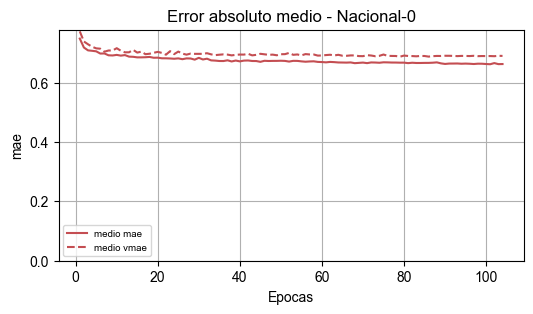

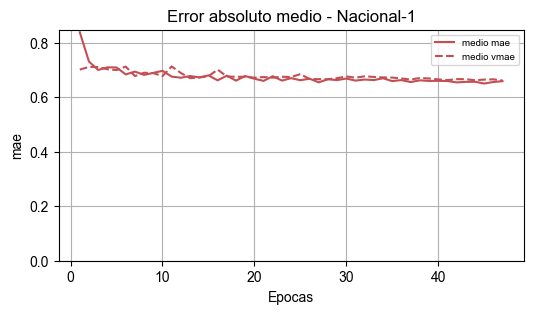

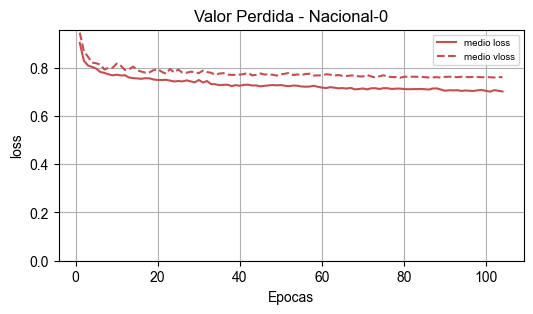

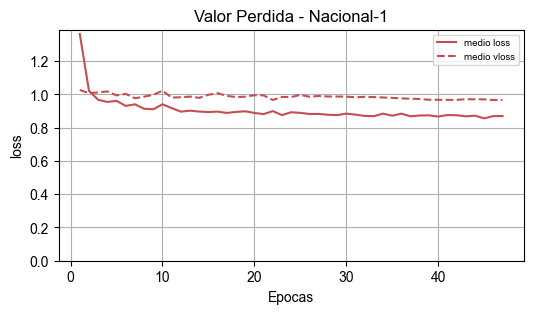

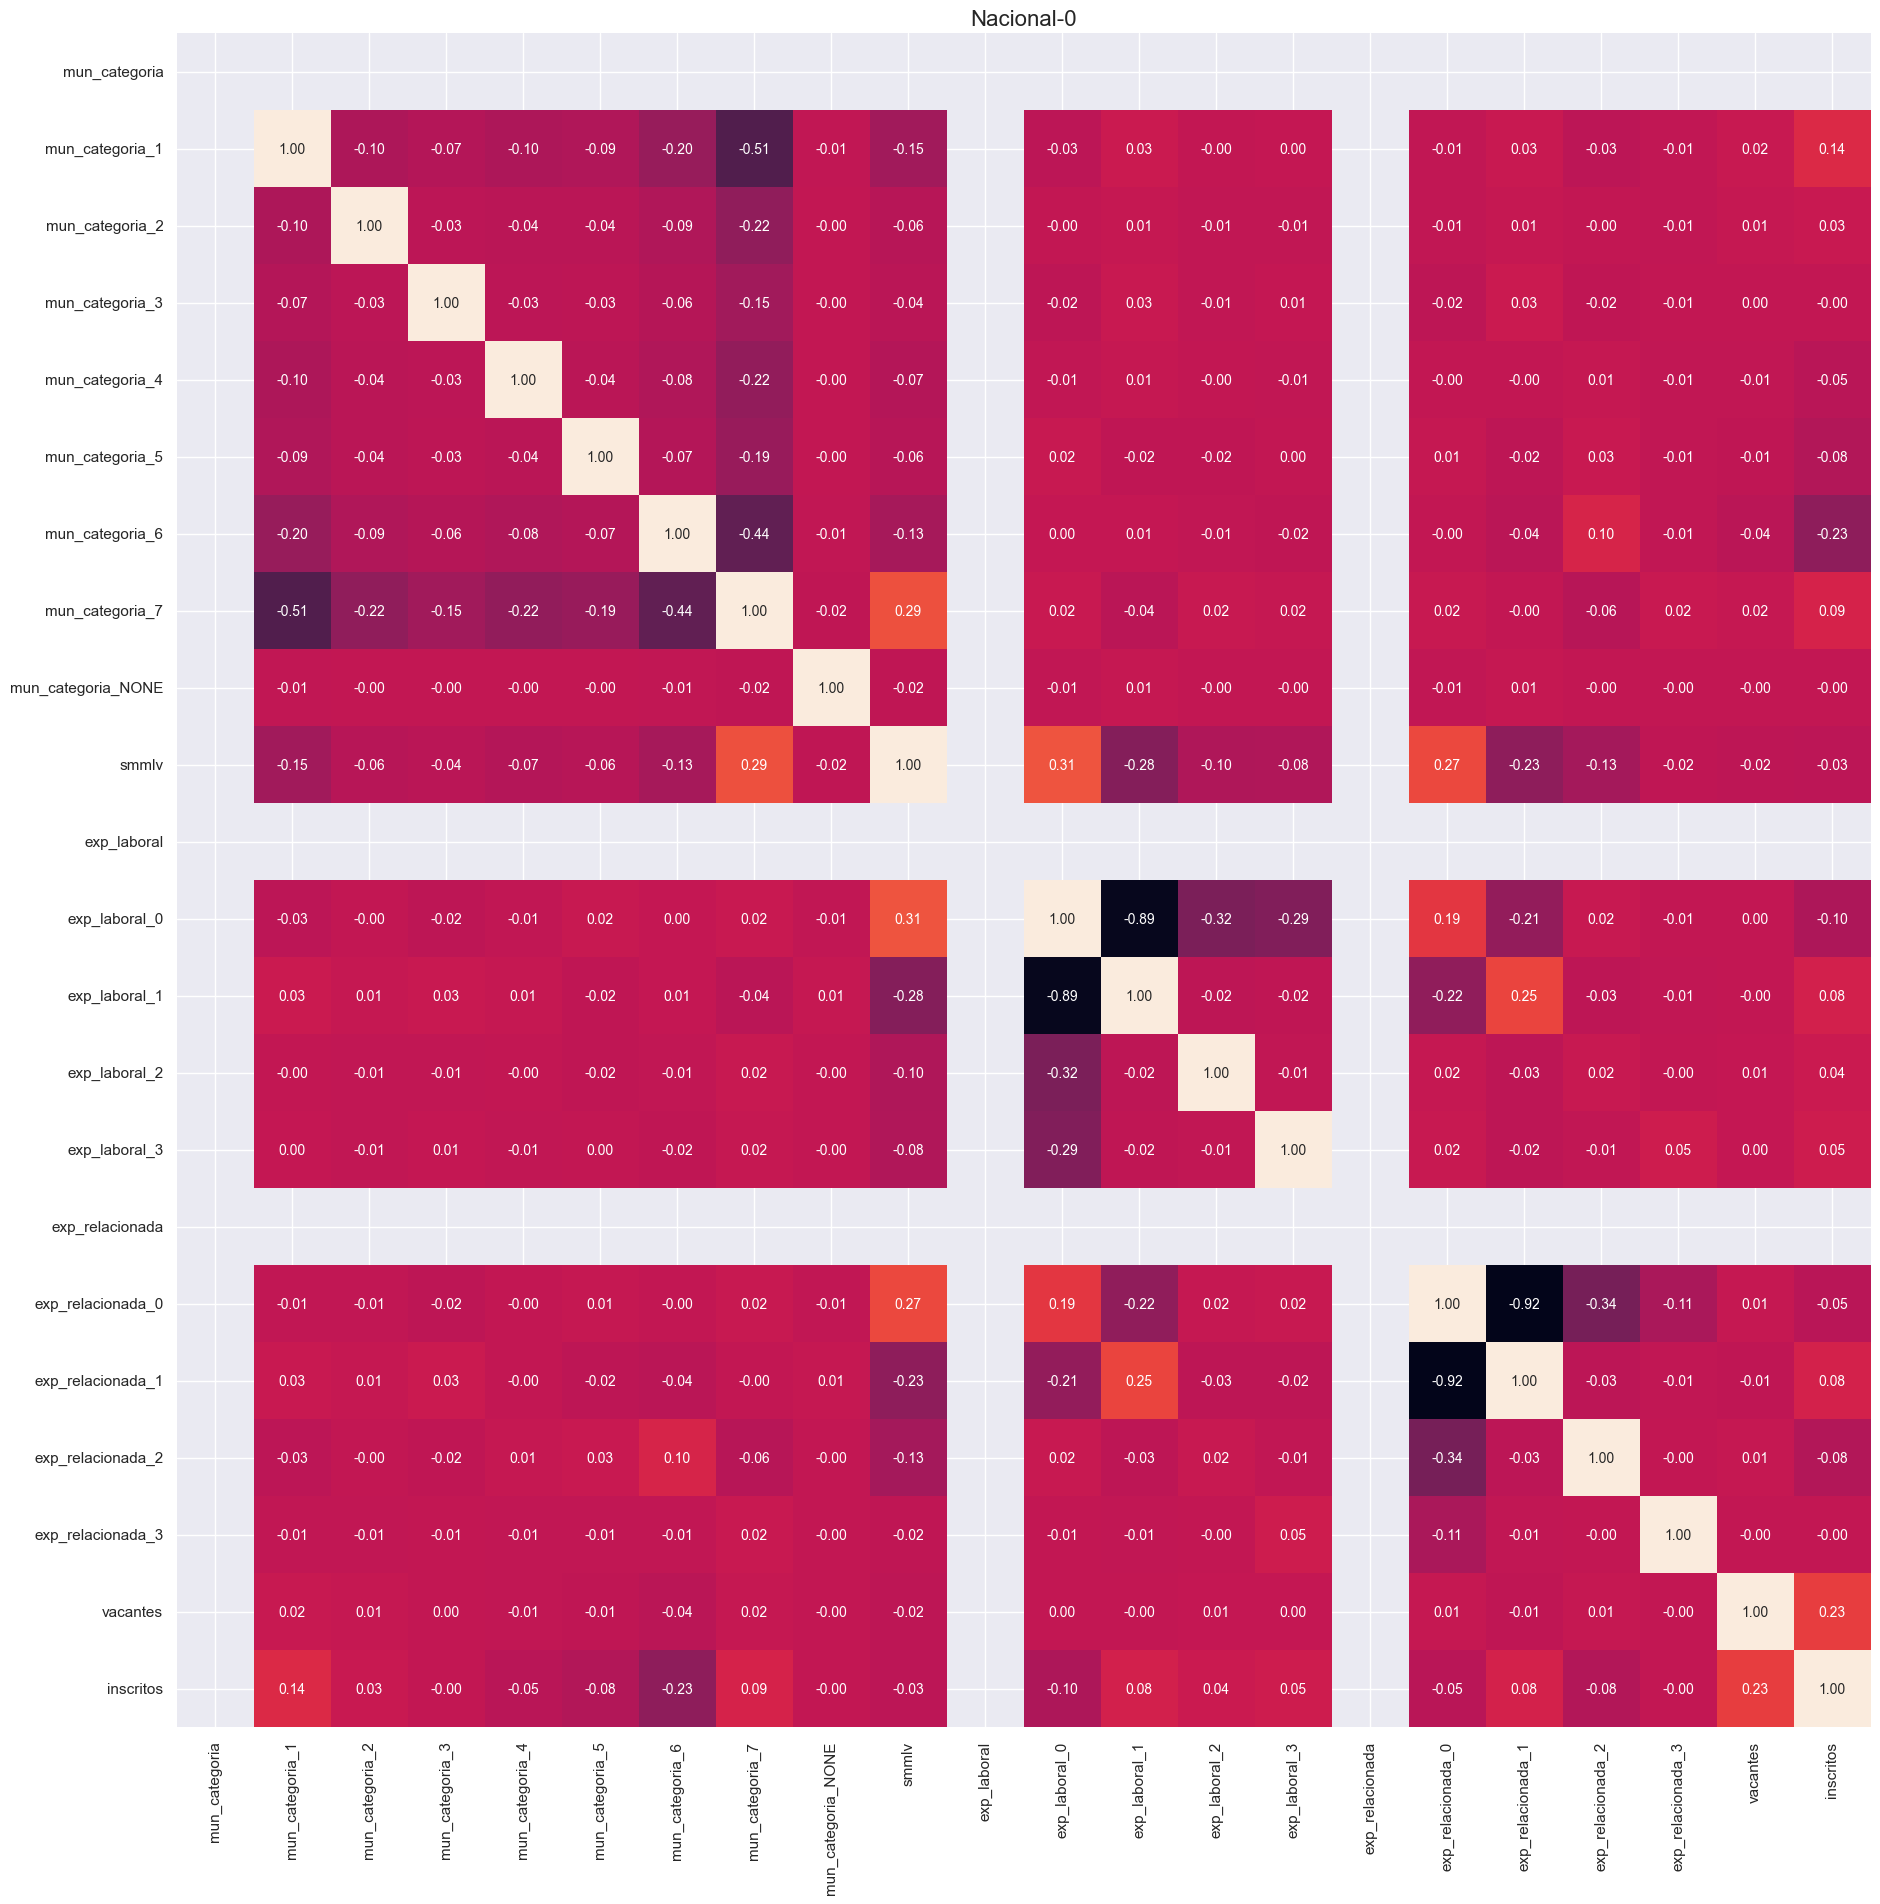

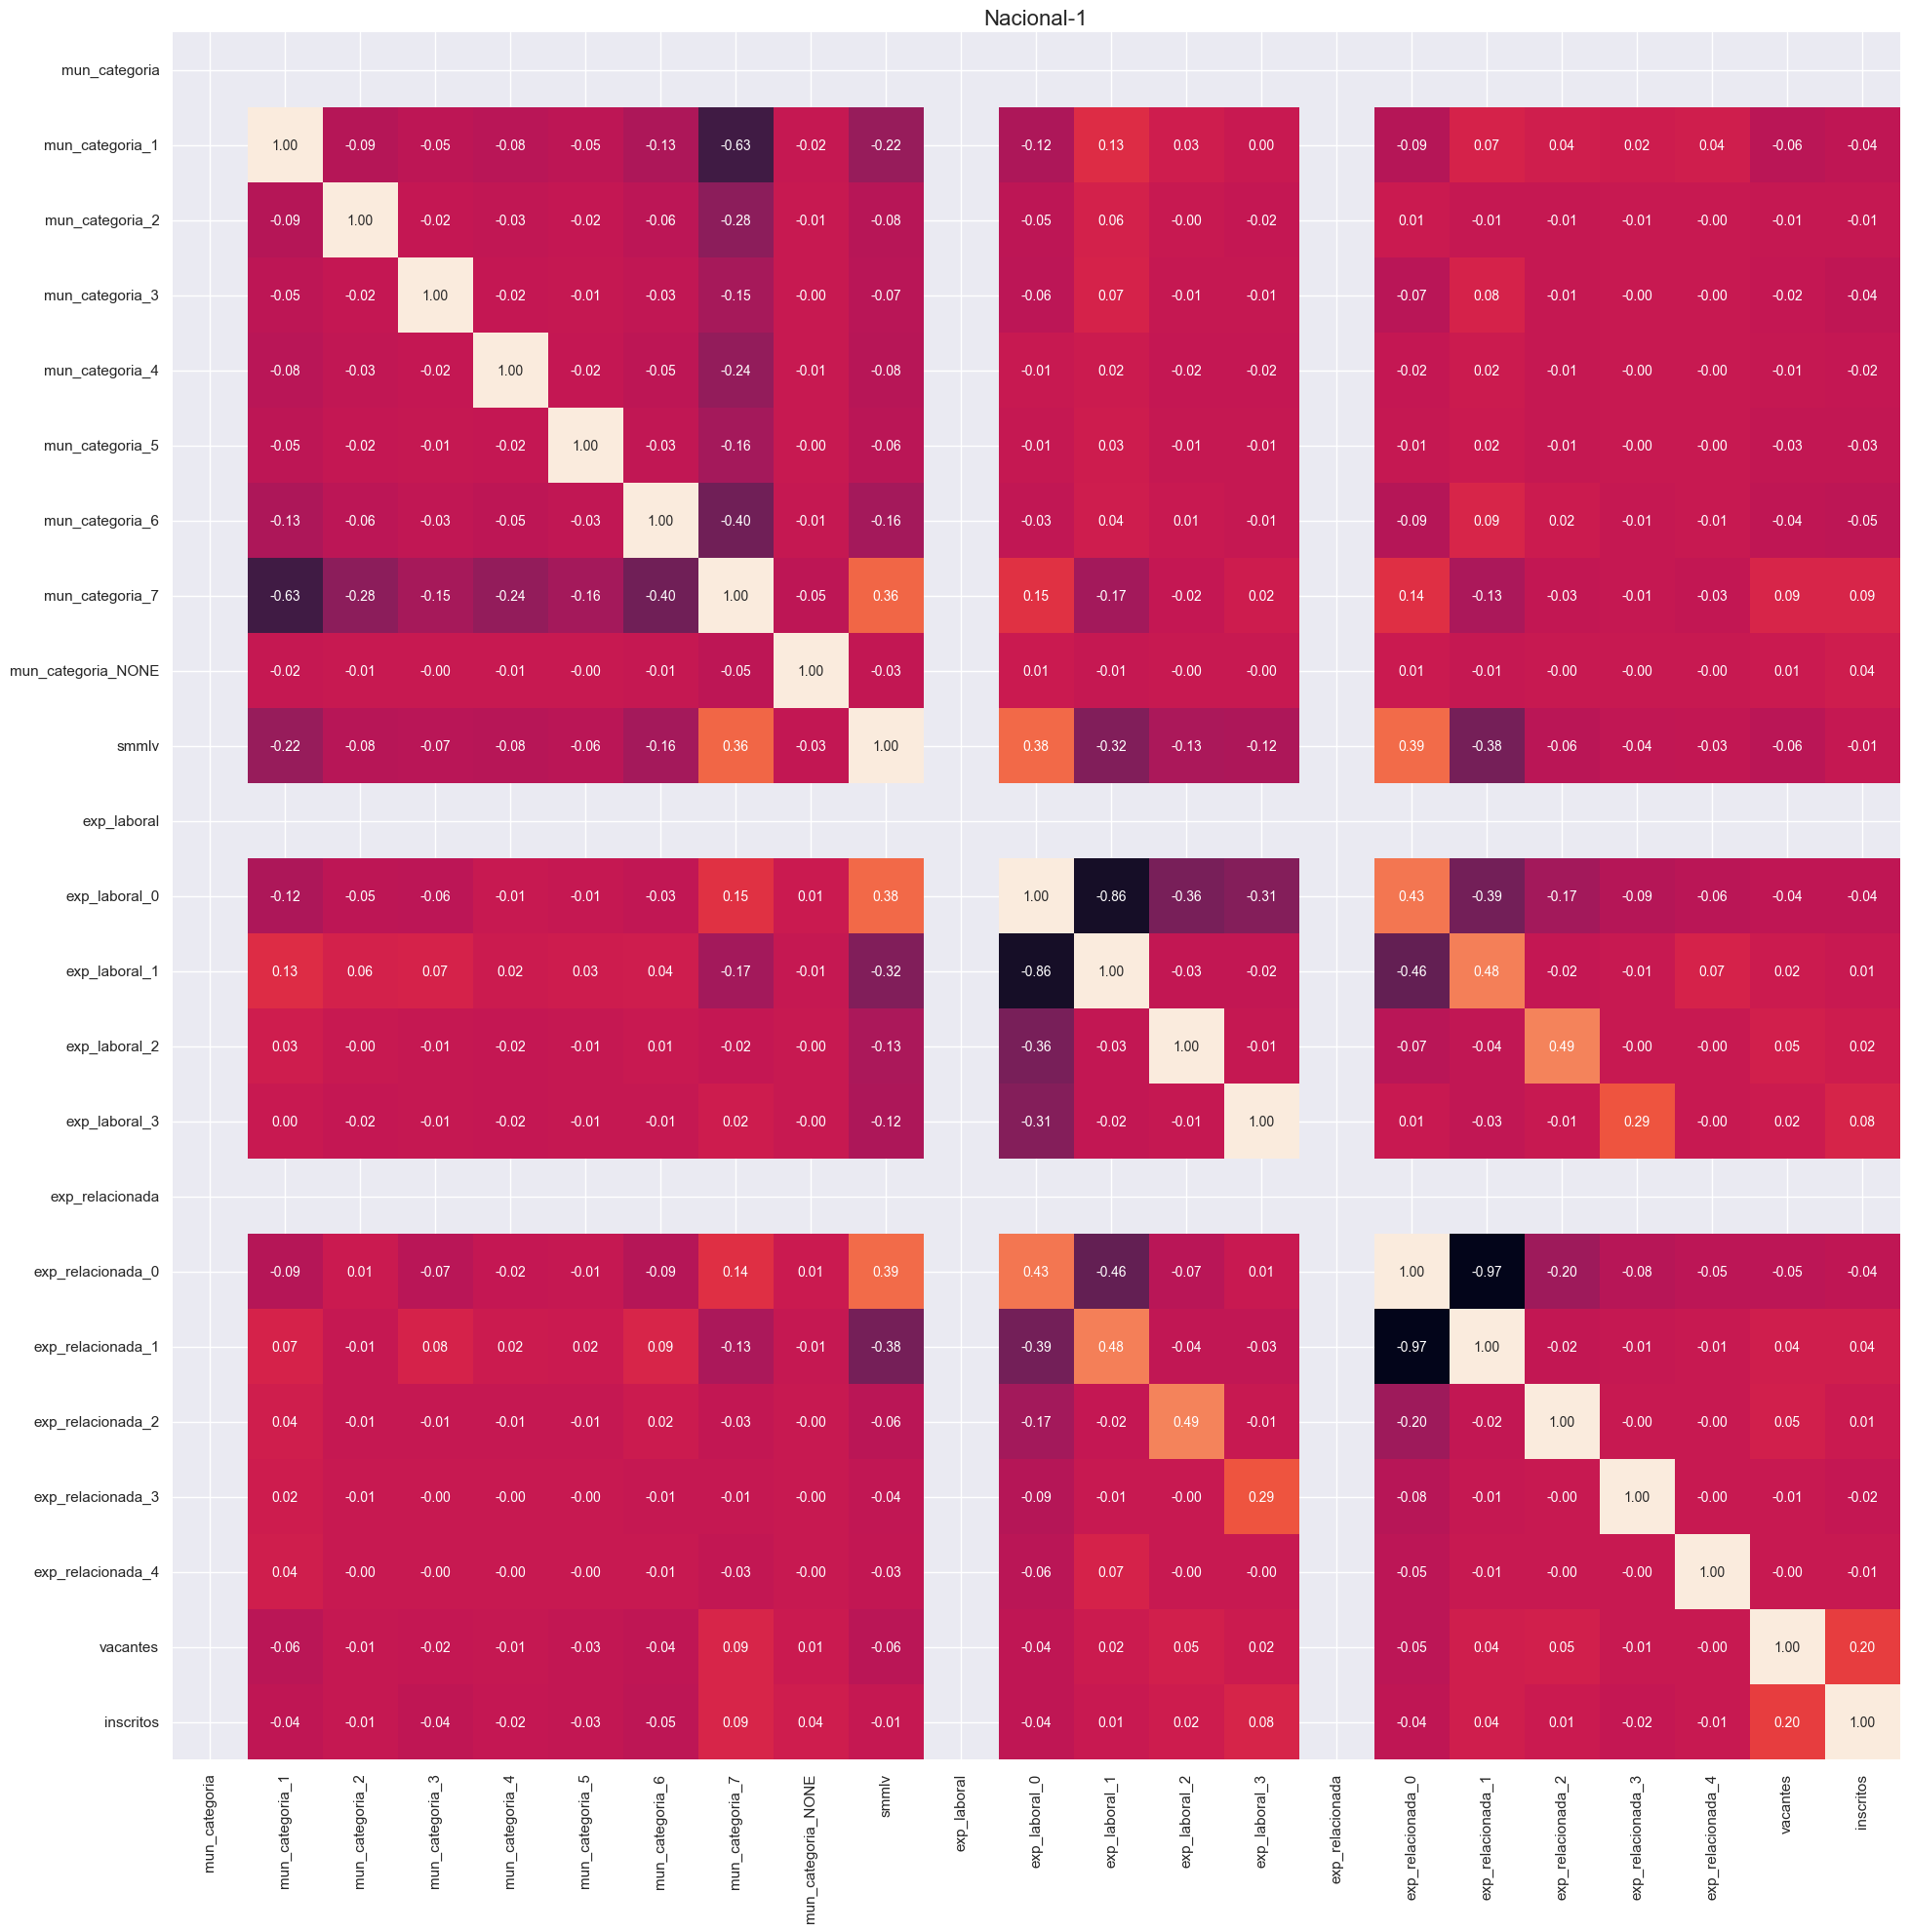

In [9]:
%%time
# ### Exportar resultados en Excel, PDF, texto
if not dfCostos.empty:
    lprint("Inicio - Exportar resultados a Excel y PDF")
    nombre = load_config()['output_dir'] + 'Resultados_' + str(ejecucion)+"_"+time.strftime("%y%m%d_%H%M%S")
    fResultadosExcel(ejecucion, nombre)
    fResultadosTexto(Dict, nombre)
    fResultadosGraficas(Dict, dfEmpleo, nombre)
    rArchivoZip(nombre)
    lprint(f"FIN - Resultados en Excel y PDF {nombre}")
else:
    lprint("Convocatoria no seleccionada")
lprint("FIN del Pipeline")

In [ ]:
base0 = Dict['Escena61']['dfModelo']
base1 = pd.concat([Dict['Escena61']['DatosX'], pd.DataFrame(Dict['Escena61']['DatosY'], columns=['inscritos'])], axis=1)
base2 = pd.DataFrame(Dict['Escena61']['X'], columns=['smmlv', 'vacantes', 'concurso_ascenso_False', 'concurso_ascenso_True',
       'reqs_estudio', 'reqs_estudio_DOCTORADO',
       'reqs_estudio_ESPECIALIZACION PROFESIONAL', 'reqs_estudio_MAESTRIA',
       'reqs_estudio_PROFESIONAL', 'reqs_estudio_TECNICO PROFESIONAL',
       'reqs_estudio_TECNOLOGICO', 'nivel', 'nivel_ASISTENCIAL',
       'nivel_PROFESIONAL', 'nivel_TECNICO'])

with pd.ExcelWriter("EjemploDatos.xlsx", engine="xlsxwriter") as writer:
    base0.to_excel(writer, sheet_name="BASE0", index=False)
    base1.to_excel(writer, sheet_name="BASE1", index=False)
    base2.to_excel(writer, sheet_name="BASE2", index=False)
    pd.DataFrame(Dict['Escena61']['Y']).to_excel(writer, sheet_name="Y", index=False)

# 
# 
### Convocatorias por Excel

#### Min Trabajo

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\B.ProyeccionRedesNeuronales\Pruebas MinTrabajo\\"
filtro = "Reporte OPEC 4.0 Ministerio de trabajo 13-03-2024.xlsx"
dfExcel = fLeerExcel(carpeta,filtro,'BASE',0)
dfExcel.tail(3)

In [ ]:
# dfConv = dfExcel[['no_emp_simo','vacantes','municipio']]
# dfConv = dfConv.rename(columns={'no_emp_simo':'empleo_id','municipio':'cod_dane'})
# dfConv = dfConv.groupby(['empleo_id']).sum()[['vacantes']].reset_index()
# dfConv

In [ ]:
dfCostos = bdConvocatoriaExcel(dfExcel)
dfCostos = dfCostos.rename(columns={'cod_dane':'dane_entidad','xcod_dane':'cod_dane'})

dfMuni = bdMunicipio()
dfMuni = dfMuni.rename(columns={'categoria':'mun_categoria'})
dfMuni = dfMuni[['cod_dane','mun_categoria']]

dfCostos = pd.merge(dfCostos,dfMuni,on='cod_dane',how='left')

# 
# 
## Anteriores Convocatorias

#### Contraloria por excel

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\C.Costos_ProyeccionRedesNeuronales\Pruebas Contralorias\\"
filtro = "Contralorias_20230620.xlsx"
dfConv = fLeer_excel(carpeta,filtro,'BASE',0)

#### EON noviembre

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\C.Costos_ProyeccionRedesNeuronales\Pruebas EON\\"
filtro = "2. OPEC ENTIDADES ORDEN NACIONAL 31102023 - CON MINTIC.xlsx"
dfConv = fLeer_excel(carpeta,filtro,'EON',0)

#### Neiva

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\C.Costos_ProyeccionRedesNeuronales\Pruebas Neiva\\"
filtro = "2023-06-01_Reporte OPEC Neiva GLPI.xlsx"
dfConv = fLeer_excel(carpeta,filtro,'BASE',0)

#### Aeronautica (Excel)

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\C.Costos_ProyeccionRedesNeuronales\Pruebas Aerocivil\\"
filtro = "BaseAeronauticaCivil.xlsx"
dfCostos = fLeer_excel(carpeta,filtro,'BASE',0)

#### DIAN (Excel)

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\C.Costos_ProyeccionRedesNeuronales\Prueba DIAN\\"
cArchivo = "opec.xlsx"
dfCostos = fLeer_excel(carpeta,cArchivo,'BASE',0)

#### CNSC (Excel)

In [ ]:
carpeta = r"D:\OneDrive - COMISIÓN NACIONAL DEL SERVICIO CIVIL\C.Costos_ProyeccionRedesNeuronales\Pruebas CNSC\\"
filtro = "EmpleosCNSC.xlsx"
dfConv = fLeer_excel(carpeta,filtro,'BASE',0)

#### Combinar con Experiencia y municipios

In [ ]:
dfExp2 = bdEmpleoExperiencia()
dfCostos = pd.merge(dfCostos,dfExp2, on = 'empleo_id', how= 'inner')

dfMuni = bdMunicipio()
dfMuni = dfMuni.rename(columns={'categoria':'mun_categoria'})
dfMuni = dfMuni[['cod_dane','mun_categoria']]

dfCostos = pd.merge(dfCostos,dfMuni,on='cod_dane',how='left')

#### Proyección Distrito 6

In [ ]:
%%time
empleos = dfExcel['empleo_id'].to_list()
filtro = f" empleo_id in ({', '.join(map(str, empleos))}) "
if True:
    dfConv = bdConvocatoriaSimo(filtro)
    dfExp2 = bdEmpleoExperiencia()
    dfCostos = pd.merge(dfConv,dfExp2, on = 'empleo_id', how= 'inner')

#### Proyección de  (Distrito 5)

In [ ]:
if False:
    i = dfCostos[dfCostos['cod_dane']!=11001.0].index[0]
    dfCostos.loc[i,'cod_dane'] = 11001.0
    dfCostos.loc[i,'mun_categoria'] = 7
    print(i)
    dfCostos.loc[i]

#### Convocatoria Superintendencias

In [ ]:
%%time
filtro = """ conv_id in (542826305,542826475,544389377,544389630,555496146,555697417,555697586,562145401,562145491,645785181,651454242,651454463,660546105,660546305)
"""
dfConv = bdConvocatoriaSimo(filtro)
dfExp2 = bdEmpleoExperiencia()
dfCostos = pd.merge(dfConv,dfExp2, on = 'empleo_id', how= 'inner')


#### Corregir Municipio No Aplica

In [ ]:
dfCostos[dfCostos['municipio']=='No_Aplica']

In [ ]:
if True:
    datosMun = [[660729334,19001,2],[661940241,52001,1],[660729360,5001,0],
                [645791377,70001,2],[660729266,70001,2],[661938903,70001,2]]
    for dm in datosMun:
        i = dfCostos[dfCostos['vac_id']==dm[0]].index[0]
        dfCostos.loc[i,'cod_dane'] = dm[1]
        dfCostos.loc[i,'mun_categoria'] = dm[2]

# 
# 
# 

In [ ]:
# model.evaluate(test_data, test_targets, verbose= 0)

# resultado = model.predict(test_data[0:5]).flatten()
# pd.DataFrame(resultado.astype(int), columns=['Res']) 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import time
import sys
import seaborn as sns
import statsmodels.formula.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_squared_log_error
from math import sqrt, isnan

In [ ]:
import gc
gc.collect()

## Visualización de resultados

In [ ]:
for e in Dict:
    print(e)

escena = list(Dict.keys())[0]
Dict[escena]['dfModelo'].tail()

#### Descripción de resultados

In [ ]:
#dfModelo['inscritos'] = np.where(( dfModelo['inscritos'].mean() < dfModelo['inscritos']),1,dfModelo.inscritos)
#dfModelo['inscritos'] = round((dfModelo['inscritos'] / maximo)*100)

#### Evaluación de Datos de Prueba y de Entrenamiento

In [ ]:
for e in Dict:
    for i, hist in enumerate(Dict[e]['Historico']):
        print("\n",Dict[e]['Filtro']," - # Neuronas: ")
        print("Evaluar datos de Prueba:")
        print(hist['model'].evaluate(Dict[e]['test_data'], Dict[e]['test_targets']),"\n")
        print("Evaluar datos de Entrenamiento:")
        print(hist['model'].evaluate(Dict[e]['train_data'], Dict[e]['train_targets']),"\n")

In [ ]:
dfCorr = dfEmpleo
plt.figure(figsize=(8,8))
sns.set(font_scale=1)
etiquetas = dfCorr.corr().columns.tolist()
hm = sns.heatmap(dfCorr.corr().to_numpy(),
                 cbar=False,
                 annot=True,
                 square=True,
                 fmt='.2f',
                 annot_kws={'size': 10},
                 yticklabels=etiquetas,
                 xticklabels=etiquetas)
hm.set_title('SIMO', fontsize =12)

In [ ]:
for e in Dict:
    etiquetas = Dict[e]['dfModelo'].columns.tolist()
    dfCorr = Dict[e]['dfModelo']
    plt.figure(figsize=(3,3))
    sns.set(font_scale=1)
    hm = sns.heatmap(dfCorr.corr().to_numpy(),
                     cbar=False,
                     annot=True,
                     square=True,
                     fmt='.2f',
                     annot_kws={'size': 10},
                     yticklabels=etiquetas,
                     xticklabels=etiquetas)
    hm.set_title(Dict[e]['Filtro'], fontsize =16)

In [ ]:
miRango = dfEmpleo[['entidad','nivel','municipio','va_inscritos','vacantes','mun_categoria']]
miRango = miRango[~miRango['nivel'].isin(['Instructor','Directivo'])]
miRango = miRango[miRango['va_inscritos'].between(miRango['va_inscritos'].quantile(0), miRango['va_inscritos'].quantile(0.95), inclusive = True)]
sns.pairplot(miRango, hue = str('mun_categoria'))
print(miRango.shape)

In [ ]:
for e in Dict:
    miRango = Dict[e]['dfEscenario'][['smmlv','nivel','vacantes','va_inscritos']]
    miRango = miRango[miRango['va_inscritos'].between(miRango['va_inscritos'].quantile(0), miRango['va_inscritos'].quantile(1), inclusive = True)]
    sns.pairplot(miRango, hue = 'nivel')
    print(Dict[e]['Filtro'], miRango.shape)

In [ ]:
for e in Dict:
    miRango = Dict[e]['dfEscenario'][['smmlv','nivel','vacantes','va_inscritos']]
    miRango = miRango[~miRango['nivel'].isin(['Instructor','Directivo'])]
    miRango = miRango[miRango['va_inscritos'].between(miRango['va_inscritos'].quantile(0.05), miRango['va_inscritos'].quantile(0.95), inclusive = True)]
    sns.pairplot(miRango, hue = 'nivel')
    print(Dict[e]['Filtro'],miRango.shape)

##### Total de inscritos por Tipo de Entidad

In [ ]:
plt.figure(figsize=(6,4))
dfPlot = dfEmpleo.groupby('tipo_entidad')['va_inscritos'].sum().sort_values()
dfPlot.plot.pie(title='Inscritos por Tipo de Entidad');

In [ ]:
pd.DataFrame(dfPlot).sort_values(by=['va_inscritos'], ascending=False).reset_index()

#### Percentiles de inscritos por categoria del municipio

In [ ]:
for e in Dict:
    plt.figure(figsize=(5,4))
    plt.title("Inscritos por categoria del municipio - " + Dict[e]['Filtro'])
    sns.boxplot(x='mun_categoriaF',y='va_inscritos', 
            data = Dict[e]['dfModelo'][Dict[e]['dfModelo']['va_inscritos'] 
                                             < Dict[e]['dfModelo']['va_inscritos'].quantile(0.95)])
    plt.show()

#### Total de inscritos por Nivel del cargo

In [ ]:
for e in Dict:
    dfPlot = Dict[e]['dfModelo'].groupby('nivelF')['va_inscritos'].sum().sort_values(ascending=False);

    plt.xlabel("Nivel")
    plt.ylabel("# Inscritos")
    plt.title('Total inscritos por nivel - '+ Dict[e]['Filtro'])
    #plt.axis("off")
    plt.axes().get_xaxis().set_visible(False)
    x = np.arange(0,dfPlot.count(),1)
    y = dfPlot.to_numpy()
    z = dfPlot.index.to_numpy()
    plt.bar(x,y)
    for i,j,k in zip(x,y,z):
        plt.annotate(j, (i,j), textcoords="offset points", xytext=(0,0), ha='center')
        plt.annotate(int(k), (i,0), textcoords="offset points", xytext=(0,-25), ha='center', color = 'red')
    plt.show()

##### Total inscritos por SMMLV del empleo

In [ ]:
for e in Dict:
    fig = plt.figure(figsize=(8,3))
    plt.plot(Dict[e]['X'][:,4], Dict[e]['Y'], '.')
    plt.title('Total inscritos por SMMLV - '+Dict[e]['Filtro'])
    plt.xlabel('SMMLV')
    plt.ylabel('# Inscritos')
    plt.legend(['empleo'], loc='upper right')
    plt.show()

##### Total Inscritos por Vacantes del empleo

In [ ]:
for e in Dict:
    fig = plt.figure(figsize=(8,3))
    plt.plot(Dict[e]['X'][:,4], Dict[e]['Y'], '.')
    plt.title('Total Inscritos por Vacantes del empleo - '+Dict[e]['Filtro'])
    plt.xlabel('Vacantes')
    plt.ylabel('# Inscritos')
    plt.legend(['empleo'], loc='upper right')
    plt.show()

#### Inicio de la lista de OPEC

##### ver diccionarios

In [ ]:
dfS = dfEmpleo[['smmlv']]
dfS['smmlv2'] = pd.Series(list(map(lambda x: x * 2, dfEmpleo['smmlv'])))
dfS

In [ ]:
Escena = list(Dict.keys())[0]

print(Dict[Escena].keys(),'\n')
#dict_keys(['dfEscenario', 'Filtro', 'Ascenso', 'dfmun_categoria', 'dfnivel', 'dfdeno_nombre', 'dfModelo', 'dataModelo', 'entradas',
#'X', 'Y', 'train_data', 'test_data', 'train_targets', 'test_targets', 'Limites', 'num_val_samples', 'Historico'])

print(Dict[Escena]['Historico'][0].keys(),'\n')
#dict_keys(['red', 'model', 'hist', 'mae', 'vmae', 'loss', 'vloss'])

print(Dict[Escena]['Historico'][0]['red'],'\n')
#[neuronas,learnR,DropOut,epochs,batch]


# 
# 
# 

# Visualización geografica 

In [ ]:
#librerias de graficos
import seaborn as sns
import matplotlib.pyplot as plt

#librerias de geografia
from geopy.geocoders import Nominatim
import folium
#import pyspark

In [ ]:
address = 'Colombia'
geolocator = Nominatim(user_agent="ny_explorer")
location = geolocator.geocode(address)
latitude = location.latitude
longitude = location.longitude
print('The geograpical coordinate of ',address,' are {}, {}.'.format(latitude, longitude))

In [ ]:
query = """select codigo codigo_dane, municipio_categoria_id, latitud, longitud, nombre from public.lugar where municipio_categoria_id is not null """
dfMuni = fConsultaScript(openCosteo()[0],query)
dfMuni.head()

In [ ]:
for e in Dict:
    print(e, Dict[e]['Filtro'])
    print(Dict[e]['dfEscenario'].shape)

In [ ]:
dfDane = Dict[escena]['dfEscenario']
dfDane = dfDane[['codigo_dane','mun_inscritos']].groupby('codigo_dane').sum('mun_inscritos')
dfDane['codigo_dane'] = dfDane.index
dfDane.reset_index(level=None, drop=True, inplace=True, col_level=0, col_fill='')

In [ ]:
cifra = int(dfDane['mun_inscritos'].max())
cifra = (cifra,int(cifra/2))[int(str(cifra)[0]) > 4]
fraccion = 10 ** (len(str(cifra)) -2)
print(cifra,fraccion)

In [ ]:
dfMapa = pd.merge(dfMuni,dfDane,on='codigo_dane',how='left')

dfMapa = dfMapa.sort_values('mun_inscritos', ascending=False)
dfMapa = dfMapa.dropna()
dfMapa['Porc'] = round(dfMapa['mun_inscritos'] / int(dfMapa['mun_inscritos'].max()) * 25, 2)
dfMapa = dfMapa[dfMapa['Porc'] > 0]
dfMapa.reset_index(level=None, drop=True, inplace=True, col_level=0, col_fill='')
print(dfMapa.shape)
dfMapa.head(3)

In [ ]:
map_colombia = folium.Map(location=[latitude, longitude], zoom_start=6)

# add markers to map
for lat, lng, label, insc, rdo in zip(dfMapa['latitud'], dfMapa['longitud'], dfMapa['nombre'], dfMapa['mun_inscritos'], dfMapa['Porc']):
    label = folium.Popup(str(label)+'-'+str(int(insc)), parse_html=True)
    folium.CircleMarker(
        [lng, lat],
        radius=rdo,
        popup=label,
        color='black',
        fill=True,
        fill_color='gold',
        fill_opacity=0.5,
        parse_html=False).add_to(map_colombia)
    
map_colombia

In [ ]:
from folium import plugins

map_colombia = folium.Map(location=[latitude, longitude], zoom_start=5,width="100%",height="100%")
locations = list(zip(dfMapa['longitud'], dfMapa['latitud']))
cluster = plugins.MarkerCluster(
    locations=locations, 
    popups=dfMapa["mun_inscritos"].tolist(), 
    name=dfMapa["nombre"].tolist(), 
    radius=dfMapa['Porc'].tolist()
)
map_colombia.add_child(cluster)
map_colombia

#folium.plugins.MarkerCluster(locations=None, popups=None, icons=None, name=None, overlay=True, 
#                             control=True, show=True, icon_create_function=None, options=None, **kwargs)

In [ ]:
from sklearn.feature_selection import f_regression

# Define the target variable
filtered_data = dfEmpleo[dfEmpleo['conv_padre_id']==554139239].copy()


y_filtered = filtered_data['mun_inscritos']

# Exclude specified columns from features
excluded_columns = ['inscritos', 'aprobo_vrm', 'aprobo_escritas', 'mun_aprobo_vrm', 'mun_aprobo_escritas', 'mun_inscritos']
selected_columns = filtered_data.columns.difference(excluded_columns)

# Splitting numerical and categorical features
numerical_cols = filtered_data[selected_columns].select_dtypes(include=['float64', 'int64','int32']).columns
categorical_cols = filtered_data[selected_columns].select_dtypes(include=['object', 'bool']).columns

# Handle numerical columns: calculate correlation with 'mun_inscritos'
numerical_corr = filtered_data[numerical_cols].corrwith(y_filtered).sort_values(ascending=False)

# Handle categorical columns: encode and evaluate ANOVA F-value
X_encoded = pd.get_dummies(filtered_data[categorical_cols], drop_first=True)
f_values, p_values = f_regression(X_encoded, y_filtered)

# Compile results for categorical variables
anova_results_cat = pd.DataFrame({
    'Feature': X_encoded.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values(by='F-Value', ascending=False)

# Select the top 4 features based on correlation and F-value
top_numerical_features = numerical_corr.index.tolist()  # Top 2 numerical
top_categorical_features = anova_results_cat.head(20)['Feature'].tolist()  # Top 2 categorical

top_features = top_numerical_features + top_categorical_features
top_features


In [ ]:
X_encoded = pd.get_dummies(filtered_data[categorical_cols], drop_first=True)

In [ ]:
anova_results_cat = pd.DataFrame({
    'Feature': X_encoded.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values(by='F-Value', ascending=False)

In [ ]:
anova_results_cat

In [ ]:
pd.options.display.max_rows = None

In [ ]:
# Re-import necessary libraries for computation as environment might have reset
import pandas as pd
from sklearn.feature_selection import f_classif

# Reload the dataset
#file_path = '/mnt/data/nn_simo_20241108.xlsx'
#data = pd.read_excel(file_path)

# Filter the dataset by 'conv_padre' as per previous instructions
filtered_data = dfEmpleo[dfEmpleo['conv_padre'] == "PROCESO DE SELECCION PARA MUNICIPIOS DE 5ta Y 6ta CATEGORIA"]

# Target variable
y_target = filtered_data['mun_inscritos']

# Categorical variables for ANOVA evaluation without using get_dummies
categorical_cols = [ 'nivel', 'denominacion', 'concurso_ascenso']

# Encode the categorical columns by replacing categories with mean 'mun_inscritos' (mean encoding)
for col in categorical_cols:
    mean_encoded = filtered_data.groupby(col)['mun_inscritos'].mean()
    filtered_data[f'{col}_mean_encoded'] = filtered_data[col].map(mean_encoded)

# Use the mean encoded columns for ANOVA to evaluate their significance without get_dummies
X_encoded = filtered_data[[f'{col}_mean_encoded' for col in categorical_cols]]

# Perform ANOVA F-test for these encoded columns against the target
f_values, p_values = f_classif(X_encoded, y_target)

# Compile results into a DataFrame for analysis
anova_results = pd.DataFrame({
    'Feature': X_encoded.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values(by='F-Value', ascending=False)

# Display the ANOVA results
anova_results


In [ ]:
mean_encoded = filtered_data.groupby('denominacion')['mun_inscritos'].mean()
filtered_data[f'{'denominacion'}_mean'] = filtered_data['denominacion'].map(mean_encoded)

In [ ]:
from sqlalchemy.types import String

In [ ]:
  lista = fRetornaLista(openCosteo, f"""select nombre, tipo, id from {openCosteo()[1]}.np_variables where activo """)

  col_mun = ['departamento', 'municipio', 'codigo_dane', 'vacantes', 'mun_inscritos', 'mun_aprobo_vrm', 'mun_aprobo_escritas', 'mun_categoria']
  
  # si hay una variable de municipio
  if any(item in lista[0] for item in col_mun):
    df = fConsultaTabla(openCosteo, 'nn_simo')
  else:
    df = fConsultaTabla(openCosteo, 'nn_simo_unico')
    for col in col_mun:
      df[col] = None

  df = fCorregirTipoDatos(df)[0]

  if any(item in lista[0] for item in ['smmlv', 'asignacion_salarial']):
    df = df[~pd.isnull(df['smmlv'])]
    df.reset_index(drop=True, inplace=True)


In [ ]:
import pandas as pd
print(pd.__version__)

In [ ]:
import numpy as np
print(np.__version__)